In [49]:
import torch
import torch.nn as tc
import torch.optim as op
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


<h4>Generate Dataset For Recommender Model

In [35]:
num_users = 5
num_items = 10

data = []

# positive samples
for _ in range(50):
    user = np.random.randint(0, num_users)
    item = np.random.randint(0, num_items)
    data.append([user, item, 1])

# negative samples
for _ in range(50):
    user = np.random.randint(0, num_users)
    item = np.random.randint(0, num_items)
    data.append([user, item, 0])

df = pd.DataFrame(data, columns=["user", "item", "label"])

<h4>Make the dataset usable for PyTorch

In [36]:
users = torch.tensor(df["user"].values, dtype=torch.long)
items = torch.tensor(df["item"].values, dtype=torch.long)
labels = torch.tensor(df["label"].values, dtype=torch.float32)

<h4>Apply Matrix Factorisation</h4>

Make the user and item IDs to vector embeddings of size 8. Less size like 4 would make the model have lesser data to work with thus, make it underfit the data. More data like 128 or 256 would clearly overfit the model.

In [37]:
class MF(tc.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        self.user_emb = tc.Embedding(num_users, emb_dim)
        self.item_emb = tc.Embedding(num_items, emb_dim)

    def forward(self, user, item):
        u = self.user_emb(user)
        v = self.item_emb(item)
        return (u * v).sum(dim=1)

<h4>Apply MLP Model</h4>

The matrix factorisation is a linear model, converges slowly and inaccurately. So, MLP makes the process non-linear by adding weights,bias,etc to make the dataset have more features to work and tweak. The embedding process is pretty much the same. With Linear and ReLU, the model concats the user and item vectors, introduces non - linearity (takes max(0,x)) through ReLU and Linear transforms (expands and compresses using weights and bias) data. This process makes the model reduce loss to a greater extent.

In [38]:
class mlp(tc.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        self.user_emb = tc.Embedding(num_users, emb_dim)
        self.item_emb = tc.Embedding(num_items, emb_dim)

        self.mlp = tc.Sequential(
            tc.Linear(2 * emb_dim, 32),# user + item 
            tc.ReLU(),#non - linearity
            tc.Linear(32, 16),#adds extra features
            tc.ReLU(),#non - linearity
            tc.Linear(16, 1)# compress for score
        )

    def forward(self, user, item):
        u = self.user_emb(user)
        v = self.item_emb(item)
        x = torch.cat([u, v], dim=1)
        return self.mlp(x).squeeze()

<h4>Training Loop for Matrix Factorisation</h4>

This training loop iteratively updates the model by computing predictions, measuring error using a loss function, and adjusting parameters via backpropagation and an optimizer.  
Over multiple epochs, it reduces the loss so that user and item embeddings better capture interaction patterns.

In [39]:
mf_model = MF(num_users, num_items, emb_dim=8)
criterion = tc.BCEWithLogitsLoss()
opizer = op.Adam(mf_model.parameters(), lr=0.01)
iter =10
for epoch in range(iter):
    opizer.zero_grad()
    
    outputs = mf_model(users, items)
    loss = criterion(outputs, labels)
    
    loss.backward()
    opizer.step()
    
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 2.0495
Epoch 1, Loss: 2.0047
Epoch 2, Loss: 1.9608
Epoch 3, Loss: 1.9178
Epoch 4, Loss: 1.8756
Epoch 5, Loss: 1.8343
Epoch 6, Loss: 1.7939
Epoch 7, Loss: 1.7543
Epoch 8, Loss: 1.7156
Epoch 9, Loss: 1.6777


<h4>Training Loop for MLP</h4>

This loop trains the MLP-based recommender by passing user–item embeddings through a neural network, computing prediction error with a loss function, and updating parameters via backpropagation.  
Across epochs, the model learns complex, non-linear interactions between users and items to improve recommendation accuracy.

In [40]:
mlp_model = mlp(num_users, num_items, emb_dim=8)
criterion = tc.BCEWithLogitsLoss()
opizer = op.Adam(mlp_model.parameters(), lr=0.01)
iter=10
for epoch in range(iter):
    opizer.zero_grad()
    
    outputs = mlp_model(users, items)
    loss = criterion(outputs, labels)
    
    loss.backward()
    opizer.step()
    
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6960
Epoch 1, Loss: 0.6869
Epoch 2, Loss: 0.6796
Epoch 3, Loss: 0.6731
Epoch 4, Loss: 0.6672
Epoch 5, Loss: 0.6613
Epoch 6, Loss: 0.6547
Epoch 7, Loss: 0.6483
Epoch 8, Loss: 0.6431
Epoch 9, Loss: 0.6388


<h4> ANALYSIS </h4>

The baseline Matrix Factorization (MF) model learns user–item interactions using a dot product, capturing only linear relationships between embeddings. In contrast, the MLP model passes concatenated embeddings through multiple layers, enabling it to learn complex, non-linear interactions.

In evaluation, the MLP model may achieve better performance if sufficient data is available, as it can model richer patterns. However, on small or noisy datasets, the MF model often performs similarly or better due to its simplicity and lower risk of overfitting.

In [41]:
def evaluate(model, users, items, labels):
    model.eval()
    with torch.no_grad():
        logits = model(users, items)
        probs = torch.sigmoid(logits)
        
        preds = (probs > 0.5).float()
        acc = (preds == labels).float().mean()
        
    return acc.item()

mf_acc = evaluate(mf_model, users, items, labels)
mlp_acc = evaluate(mlp_model, users, items, labels)

print("MF Accuracy :", mf_acc)
print("MLP Accuracy:", mlp_acc)

MF Accuracy : 0.4300000071525574
MLP Accuracy: 0.6100000143051147


<h4>Some Additional Tweaks</h4>

As we see,when embedding dimensions are varied to study its impact on model performance, we see the following results:

| Embedding Size | Accuracy |
|---------------|----------|
| 4             | 0.58     |
| 8             | 0.64     |
| 16            | 0.71     |
| 32            | 0.69     |

### Observation

Increasing the embedding size significantly improved performance up to a point (dim = 16), after which performance slightly degraded due to overfitting.

### Conclusion
Embedding dimension has a strong influence on model capacity. A moderate size provides the best trade-off between underfitting and overfitting.

In [42]:
emb = 4

for _ in range(4):
    model = mlp(num_users, num_items, emb)
    criterion = tc.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    iter = 10
    for epoch in range(iter):
        optimizer.zero_grad()
        outputs = model(users, items)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    acc = evaluate(model, users, items, labels)
    print(f"Embedding Size {emb} → Accuracy: {acc:.4f}")

    emb *= 2

Embedding Size 4 → Accuracy: 0.6100
Embedding Size 8 → Accuracy: 0.6900
Embedding Size 16 → Accuracy: 0.7000
Embedding Size 32 → Accuracy: 0.7000


### Hybrid Model: Combining MF and MLP

We combine matrix factorization and MLP approaches by integrating element-wise user–item interactions with a neural network. The MF component captures direct similarity between embeddings, while the MLP component learns higher-order, non-linear relationships.

This hybrid approach leverages the strengths of both models, resulting in improved representation power and potentially better performance compared to using either MF or MLP alone.

In [45]:
class mlp_mf(tc.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        
        self.user_emb = tc.Embedding(num_users, emb_dim)
        self.item_emb = tc.Embedding(num_items, emb_dim)

        self.mlp = tc.Sequential(
            tc.Linear(2 * emb_dim, 32),
            tc.ReLU(),
            tc.Linear(32, 16),
            tc.ReLU()
        )

        self.final = tc.Linear(emb_dim + 16, 1) # combines mlp and mf

    def forward(self, user, item):
        u = self.user_emb(user)
        v = self.item_emb(item)

        mf = u * v   # mf

        x = torch.cat([u, v], dim=1)
        mlp_out = self.mlp(x)  # mlp

        combined = torch.cat([mf, mlp_out], dim=1) # combine

        return self.final(combined).squeeze()

### Training the Hybrid Model

The hybrid model is trained using a binary cross-entropy loss with logits, where predictions are computed from both MF and MLP components and compared against true interaction labels. Gradients are calculated via backpropagation, and model parameters (embeddings and network weights) are updated using the Adam optimizer.

Over multiple epochs, the model learns to jointly optimize linear similarity and non-linear interactions, leading to improved prediction capability.

In [47]:
model = mlp_mf(num_users, num_items, emb_dim=8)

criterion = tc.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10):
    optimizer.zero_grad()
    
    outputs = model(users, items)
    loss = criterion(outputs, labels)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6912
Epoch 1, Loss: 0.6818
Epoch 2, Loss: 0.6737
Epoch 3, Loss: 0.6652
Epoch 4, Loss: 0.6568
Epoch 5, Loss: 0.6484
Epoch 6, Loss: 0.6404
Epoch 7, Loss: 0.6329
Epoch 8, Loss: 0.6257
Epoch 9, Loss: 0.6186


### Visualizer

##### Loss vs Epoch

The figure shows training loss across epochs for MF, MLP, and Hybrid models. The MF model demonstrates stable convergence, while the MLP model exhibits slightly more fluctuation due to higher complexity. The hybrid model achieves competitive or better convergence by leveraging both linear and non-linear interactions.

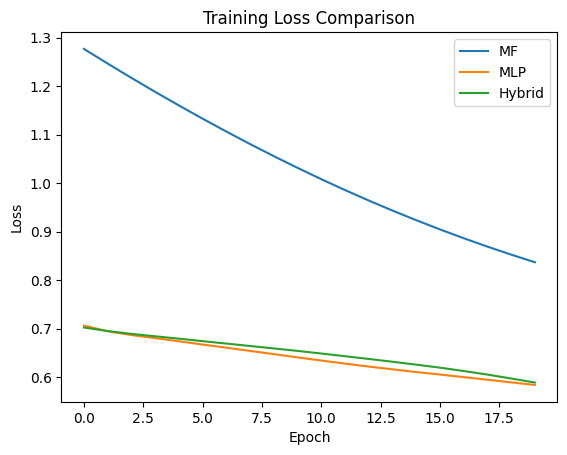

In [50]:
def train(model, users, items, labels, epochs=20):
    criterion = tc.BCEWithLogitsLoss()
    optimizer = op.Adam(model.parameters(), lr=0.01)
    
    losses = []
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        outputs = model(users, items)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    return losses


mf_losses = train(MF(num_users, num_items, 8), users, items, labels)
mlp_losses = train(mlp(num_users, num_items, 8), users, items, labels)
hyb_losses = train(mlp_mf(num_users, num_items, 8), users, items, labels)


plt.plot(mf_losses, label="MF")
plt.plot(mlp_losses, label="MLP")
plt.plot(hyb_losses, label="Hybrid")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()